In [1]:
# Install dependencies
!pip install -q kaggle

# Upload your kaggle.json
from google.colab import files
files.upload()

# Setup Kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download dataset
!kaggle datasets download -d vbookshelf/v2-plant-seedlings-dataset
!unzip v2-plant-seedlings-dataset.zip -d data

Streaming output truncated to the last 5000 lines.
  inflating: data/nonsegmentedv2/Charlock/308.png  
  inflating: data/nonsegmentedv2/Charlock/309.png  
  inflating: data/nonsegmentedv2/Charlock/31.png  
  inflating: data/nonsegmentedv2/Charlock/310.png  
  inflating: data/nonsegmentedv2/Charlock/311.png  
  inflating: data/nonsegmentedv2/Charlock/312.png  
  inflating: data/nonsegmentedv2/Charlock/313.png  
  inflating: data/nonsegmentedv2/Charlock/314.png  
  inflating: data/nonsegmentedv2/Charlock/315.png  
  inflating: data/nonsegmentedv2/Charlock/316.png  
  inflating: data/nonsegmentedv2/Charlock/317.png  
  inflating: data/nonsegmentedv2/Charlock/318.png  
  inflating: data/nonsegmentedv2/Charlock/319.png  
  inflating: data/nonsegmentedv2/Charlock/32.png  
  inflating: data/nonsegmentedv2/Charlock/320.png  
  inflating: data/nonsegmentedv2/Charlock/321.png  
  inflating: data/nonsegmentedv2/Charlock/322.png  
  inflating: data/nonsegmentedv2/Charlock/323.png  
  inflating: da

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import numpy as np

In [3]:
IMAGE_SIZE = 64
BATCH_SIZE = 32

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize((0.5,)*3, (0.5,)*3)
])

test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,)*3, (0.5,)*3)
])

dataset = ImageFolder("data", transform=train_transform)

# Split dataset (70/15/15)
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_data, val_data, test_data = random_split(dataset, [train_size, val_size, test_size])

# Apply test transform to val/test
val_data.dataset.transform = test_transform
test_data.dataset.transform = test_transform

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE)

num_classes = len(dataset.classes)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3*IMAGE_SIZE*IMAGE_SIZE, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.model(x)

In [5]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

In [12]:
def train_model(model, train_loader, val_loader, epochs=15, lr=0.001):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

    train_losses, val_losses = [], []

    for epoch in range(epochs):
        # ===== TRAIN =====
        model.train()
        total_loss = 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            out = model(x)
            loss = criterion(out, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * x.size(0)

        # ✅ AVERAGE TRAIN LOSS
        total_loss /= len(train_loader.dataset)
        train_losses.append(total_loss)

        # ===== VALIDATION =====
        model.eval()
        val_loss = 0

        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                out = model(x)

                loss = criterion(out, y)
                val_loss += loss.item() * x.size(0)

        # ✅ AVERAGE VAL LOSS
        val_loss /= len(val_loader.dataset)
        val_losses.append(val_loss)

        print(f"Epoch {epoch+1} | Train Loss: {total_loss:.4f} | Val Loss: {val_loss:.4f}")

    return model, train_losses, val_losses

In [13]:
def evaluate(model, loader):
    model.eval()
    preds, labels = [], []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            out = model(x)

            preds.extend(torch.argmax(out, 1).cpu().numpy())
            labels.extend(y.numpy())

    acc = accuracy_score(labels, preds)
    return acc, preds, labels

In [14]:
mlp = MLP()
cnn = CNN()

mlp, mlp_train, mlp_val = train_model(mlp, train_loader, val_loader, epochs=20)
cnn, cnn_train, cnn_val = train_model(cnn, train_loader, val_loader, epochs=20)

Epoch 1 | Train Loss: 2.0048 | Val Loss: 2.0027
Epoch 2 | Train Loss: 1.9456 | Val Loss: 1.9799
Epoch 3 | Train Loss: 1.8932 | Val Loss: 1.8827
Epoch 4 | Train Loss: 1.8097 | Val Loss: 1.8055
Epoch 5 | Train Loss: 1.7557 | Val Loss: 1.7994
Epoch 6 | Train Loss: 1.7123 | Val Loss: 1.7497
Epoch 7 | Train Loss: 1.7249 | Val Loss: 1.6564
Epoch 8 | Train Loss: 1.6652 | Val Loss: 1.6862
Epoch 9 | Train Loss: 1.6578 | Val Loss: 1.6946
Epoch 10 | Train Loss: 1.6364 | Val Loss: 1.6426
Epoch 11 | Train Loss: 1.6498 | Val Loss: 1.6162
Epoch 12 | Train Loss: 1.6377 | Val Loss: 1.6051
Epoch 13 | Train Loss: 1.6244 | Val Loss: 1.6700
Epoch 14 | Train Loss: 1.6038 | Val Loss: 1.6455
Epoch 15 | Train Loss: 1.5848 | Val Loss: 1.6735
Epoch 16 | Train Loss: 1.6001 | Val Loss: 1.5843
Epoch 17 | Train Loss: 1.5887 | Val Loss: 1.6034
Epoch 18 | Train Loss: 1.5879 | Val Loss: 1.5856
Epoch 19 | Train Loss: 1.6033 | Val Loss: 1.6116
Epoch 20 | Train Loss: 1.5991 | Val Loss: 1.5751
Epoch 1 | Train Loss: 1.9459 

In [15]:
# Try different learning rates
cnn_lr1, _, _ = train_model(CNN(), train_loader, val_loader, epochs=10, lr=0.001)
cnn_lr2, _, _ = train_model(CNN(), train_loader, val_loader, epochs=10, lr=0.0005)

Epoch 1 | Train Loss: 1.9478 | Val Loss: 1.9419
Epoch 2 | Train Loss: 1.9186 | Val Loss: 1.9411
Epoch 3 | Train Loss: 1.8064 | Val Loss: 1.6117
Epoch 4 | Train Loss: 1.5571 | Val Loss: 1.4560
Epoch 5 | Train Loss: 1.4199 | Val Loss: 1.3059
Epoch 6 | Train Loss: 1.3141 | Val Loss: 1.2591
Epoch 7 | Train Loss: 1.2581 | Val Loss: 1.2307
Epoch 8 | Train Loss: 1.2117 | Val Loss: 1.1966
Epoch 9 | Train Loss: 1.1773 | Val Loss: 1.1826
Epoch 10 | Train Loss: 1.1582 | Val Loss: 1.1316
Epoch 1 | Train Loss: 1.9442 | Val Loss: 1.9440
Epoch 2 | Train Loss: 1.8658 | Val Loss: 1.6460
Epoch 3 | Train Loss: 1.5005 | Val Loss: 1.4229
Epoch 4 | Train Loss: 1.3620 | Val Loss: 1.2556
Epoch 5 | Train Loss: 1.2724 | Val Loss: 1.2170
Epoch 6 | Train Loss: 1.2105 | Val Loss: 1.1609
Epoch 7 | Train Loss: 1.1508 | Val Loss: 1.1431
Epoch 8 | Train Loss: 1.1293 | Val Loss: 1.1181
Epoch 9 | Train Loss: 1.1043 | Val Loss: 1.1392
Epoch 10 | Train Loss: 1.0752 | Val Loss: 1.1055


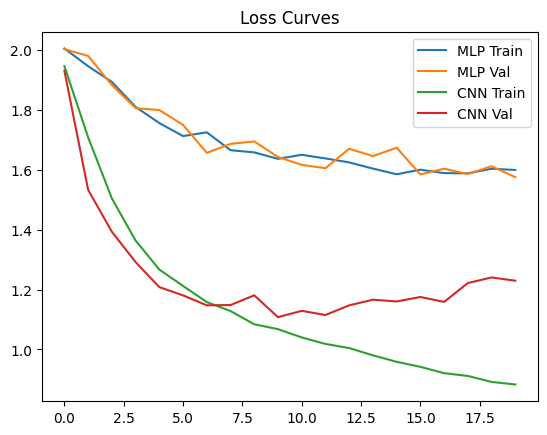

In [16]:
plt.plot(mlp_train, label="MLP Train")
plt.plot(mlp_val, label="MLP Val")
plt.plot(cnn_train, label="CNN Train")
plt.plot(cnn_val, label="CNN Val")
plt.legend()
plt.title("Loss Curves")
plt.show()

In [17]:
mlp_acc, mlp_preds, y_true = evaluate(mlp, test_loader)
cnn_acc, cnn_preds, _ = evaluate(cnn, test_loader)

print("MLP Accuracy:", mlp_acc)
print("CNN Accuracy:", cnn_acc)

MLP Accuracy: 0.5123271196632592
CNN Accuracy: 0.3319302465423933


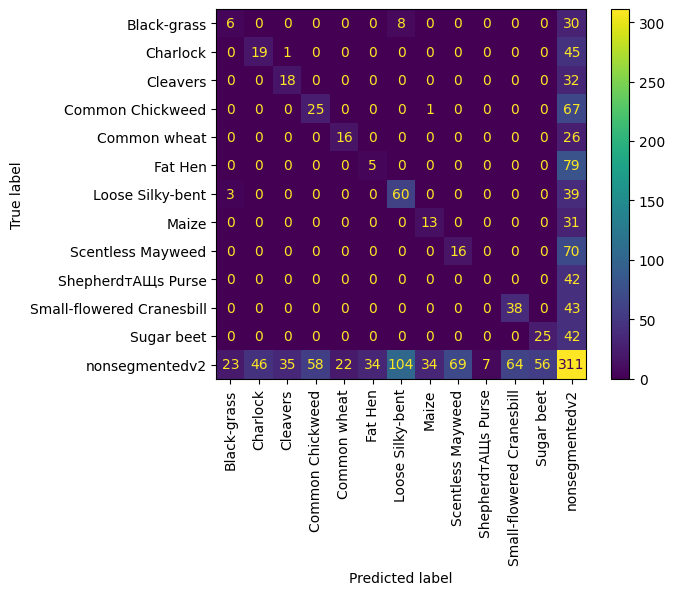

In [18]:
cm = confusion_matrix(y_true, cnn_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=dataset.classes)
disp.plot(xticks_rotation=90)
plt.show()